 ⬅️ Click the 3 line menu \(㆔\) on the left for table of contents

Click Run ▶️ in top right corner ↗ to refresh data if needed\.

<hr>

This app provides aggregate information for one program\.

🔐 Program identity hidden\.

🔒 All data are anonymous\.

<hr>

In [1]:
import pandas as pd
from tabulate import tabulate
# Import chemdict from S3 bucket with nightly pull
chemdict = pd.read_csv('/datasets/full-access/chemdict.csv')

# Rename 'substances' to 'substance'
chemdict = chemdict.rename(columns={'substances': 'substance'})

# Total UNC

Descriptive summary for entire UNC drug checking service\.

In [2]:
import pandas as pd 
import pickle

# Import card data from CMS S3, treating NaN as blank
card = pd.read_csv('/datasets/cms/analysis_dataset.csv', na_filter=False, low_memory=False)

# Import lab data from CMS S3, treating NaN as blank
lab = pd.read_csv('/datasets/cms/lab_detail.csv')

# Replace NaT in 'date_collect' column with blank in 'card' dataframe
card['date_collect'].fillna(pd.NaT, inplace=True)

# Convert the 'date_complete' column to datetime with specified format
lab['date_complete'] = pd.to_datetime(lab['date_complete'], format='%d%b%Y', errors='coerce')
card['date_complete'] = pd.to_datetime(card['date_complete'], format='%d%b%Y', errors='coerce')

# Convert the 'date_collect' column to datetime with specified format
card['date_collect'] = pd.to_datetime(card['date_collect'], format='%d%b%Y', errors='coerce')

# Fix data entry error if state="Fl" replace with "FL"
card['state'] = card['state'].str.replace('Fl', 'FL')

# Merge lab and card dataframes on 'sampleid', keeping only columns from lab if duplicate column names exist
merged = pd.merge(lab, card, on='sampleid', suffixes=('', '_drop'))
merged = merged[[c for c in merged.columns if not c.endswith('_drop')]]

# Unpickle the variables from summary pickle file for all UNC samples
with open('/datasets/full-access/summary_data.pkl', 'rb') as f:
    summary_data = pickle.load(f)

latest_date = summary_data['latest_date']
formatted_date = summary_data['formatted_date']
unique_sampleid_count = summary_data['unique_sampleid_count']
unique_substances_count = summary_data['unique_substances_count']
unique_programs_count = summary_data['unique_programs_count']
unique_state_count = summary_data['unique_state_count']
unique_county_count = summary_data['unique_county_count']

print(f'== UNC FULL SERVICE STATS ==')
print(f'Updated {formatted_date}')
print(f'{unique_sampleid_count:,} samples analyzed')
print(f'Serving {unique_programs_count} harm reduction programs')
print(f'Reaching {unique_county_count} counties in {unique_state_count} states')
print(f'{unique_substances_count} unique substances identified')


/tmp/ipykernel_115/3582705516.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  lab = pd.read_csv('/datasets/cms/lab_detail.csv')
== UNC FULL SERVICE STATS ==
Updated Monday, August 24, 2026
23,681 samples analyzed
Serving 211 harm reduction programs
Reaching 299 counties in 44 states
538 unique substances identified


<hr>

# Program summary

Data for this specific program\.

In [3]:
import datetime as dt

# Filter the 'card' dataframe where program contains "steady" (case insensitive)
card_filtered = card[card['program'].str.contains('steady', case=False, regex=True)]

# Get the unique sampleid from the filtered 'card' dataframe
unique_sampleids = card_filtered['sampleid'].unique()

# Filter the 'lab' dataframe to keep only the rows with sampleid in the unique_sampleids
lab_filtered = lab[lab['sampleid'].isin(unique_sampleids)]

# Ensure the list of unique sampleid are the same in both dataframes
card_filtered = card_filtered[card_filtered['sampleid'].isin(lab_filtered['sampleid'].unique())]

# Create merged and filtered dataframe
merged_filtered = pd.merge(lab_filtered, card_filtered, on='sampleid', suffixes=('', '_drop'))
mergedmerged_filtered = merged[[c for c in merged.columns if not c.endswith('_drop')]]

# Display message with latest date_complete, number of samples, and unique substances
latest_date_filtered = lab_filtered['date_complete'].max()
latest_date_filtered = latest_date_filtered.strftime('%A, %B %d, %Y')
unique_sampleid_count = lab_filtered['sampleid'].nunique()
unique_substances_count = lab_filtered['substance'].nunique()
unique_county_count = card_filtered['county'].nunique()
print(f'A total of {unique_sampleid_count} samples have been analyzed from this program.')
print(f'Most recent sample analyzed on {latest_date_filtered}.')
print(f'These samples came from {unique_county_count} counties.')
print(f'We have detected {unique_substances_count} unique substances in samples from this program.')

A total of 165 samples have been analyzed from this program.
Most recent sample analyzed on Friday, June 05, 2026.
These samples came from 4 counties.
We have detected 58 unique substances in samples from this program.


<hr>

# Pending samples

You can see the status of pending samples here\.

<hr>

# Completed

## Sample timeline

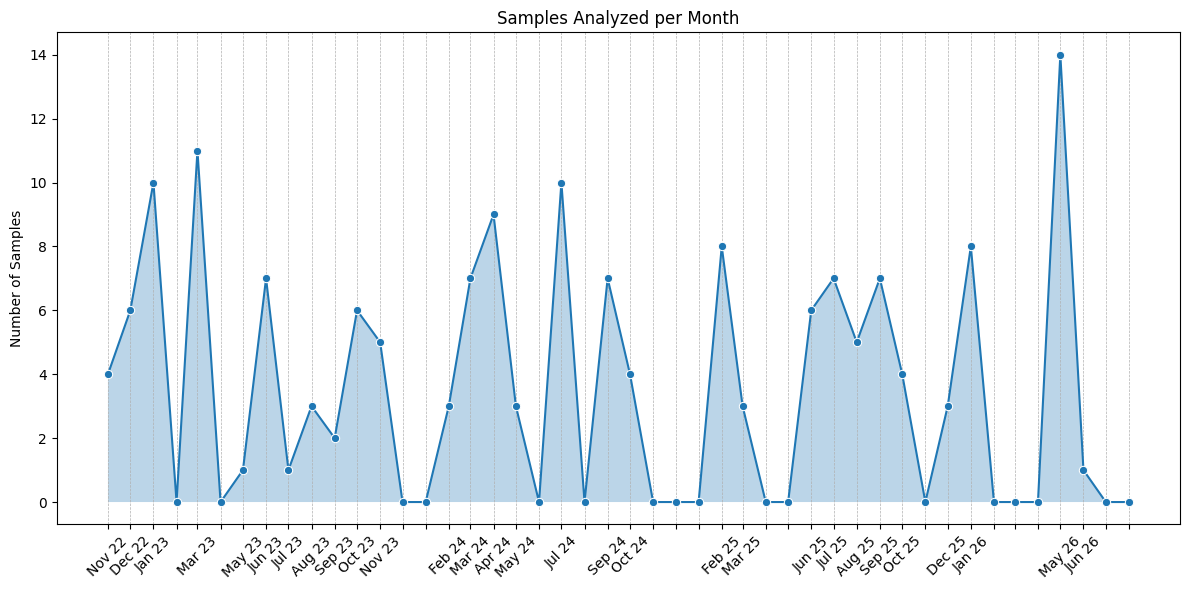

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import date_range

# Extract year and month from 'date_complete' for grouping
merged_filtered['year_month'] = merged_filtered['date_complete'].dt.to_period('M')

# Group by year_month and count unique sampleid
monthly_counts = merged_filtered.groupby('year_month')['sampleid'].nunique().reset_index()

# Generate a complete date range from the earliest to the latest month in the dataset, including the current month
current_month = pd.to_datetime('today').to_period('M')

# Update 'end' parameter to include the next month to account for samples in the current month
full_date_range = pd.Series(date_range(start=monthly_counts['year_month'].min().start_time, 
                                       end=(current_month + 1).start_time, 
                                       freq='M'))
# Convert to period for consistency in merging
full_date_range = full_date_range.dt.to_period('M')

# Merge with monthly counts to ensure all months are represented
monthly_counts = pd.merge(full_date_range.rename('year_month'), 
                          monthly_counts, 
                          on='year_month', 
                          how='left').fillna(0)

# Correct type of sampleid column
monthly_counts['sampleid'] = monthly_counts['sampleid'].astype(int)

# Convert year_month back to datetime for plotting
monthly_counts['year_month'] = monthly_counts['year_month'].dt.to_timestamp()

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_counts, x='year_month', y='sampleid', marker='o')
plt.fill_between(monthly_counts['year_month'], monthly_counts['sampleid'], alpha=0.3)
plt.title('Samples Analyzed per Month')
plt.ylabel('Number of Samples')
# Update x-ticks and labels
xticks = monthly_counts['year_month']
xlabels = [date.strftime('%b %y') if count != 0 else '' for date, count in zip(monthly_counts['year_month'], monthly_counts['sampleid'])]
plt.xticks(ticks=xticks, labels=xlabels, rotation=45)
plt.xlabel('')  # Suppress horizontal axis title
plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)  # Add vertical grid lines for non-zero months
plt.tight_layout()
plt.show()

## Links to samples

In [5]:
from IPython.display import display, HTML

# Sort card_filtered by date_collect in descending order
card_filtered = card_filtered.sort_values(by='date_collect', ascending=False)

# Create a clickable HTML table with date_collect and sampleid columns
html_table = "<table><tr><th>Date Collected</th><th>Sample ID</th></tr>"

for index, row in card_filtered.iterrows():
    if pd.notna(row['date_collect']): # Check if date_collect is not NaT
        date_collect = row['date_collect'].strftime('%B %d, %Y')  # Format date as 'January 01, 2023'
    else:
        date_collect = 'N/A'
    sampleid = row['sampleid']
    url = f"https://streetsafe.supply/results/p/{sampleid[-6:]}"
    html_table += f"<tr><td>{date_collect}</td><td><a href='{url}'>{sampleid}</a></td></tr>"

html_table += "</table>"

# Display the HTML table
display(HTML(html_table))

Date Collected,Sample ID
"May 21, 2026",604266
"May 07, 2026",604279
"May 01, 2026",604276
"May 01, 2026",604263
"May 01, 2026",604259
"May 01, 2026",604264
"May 01, 2026",604261
"April 30, 2026",604267
"April 25, 2026",604260
"April 20, 2026",604262


<hr>

# Sample info

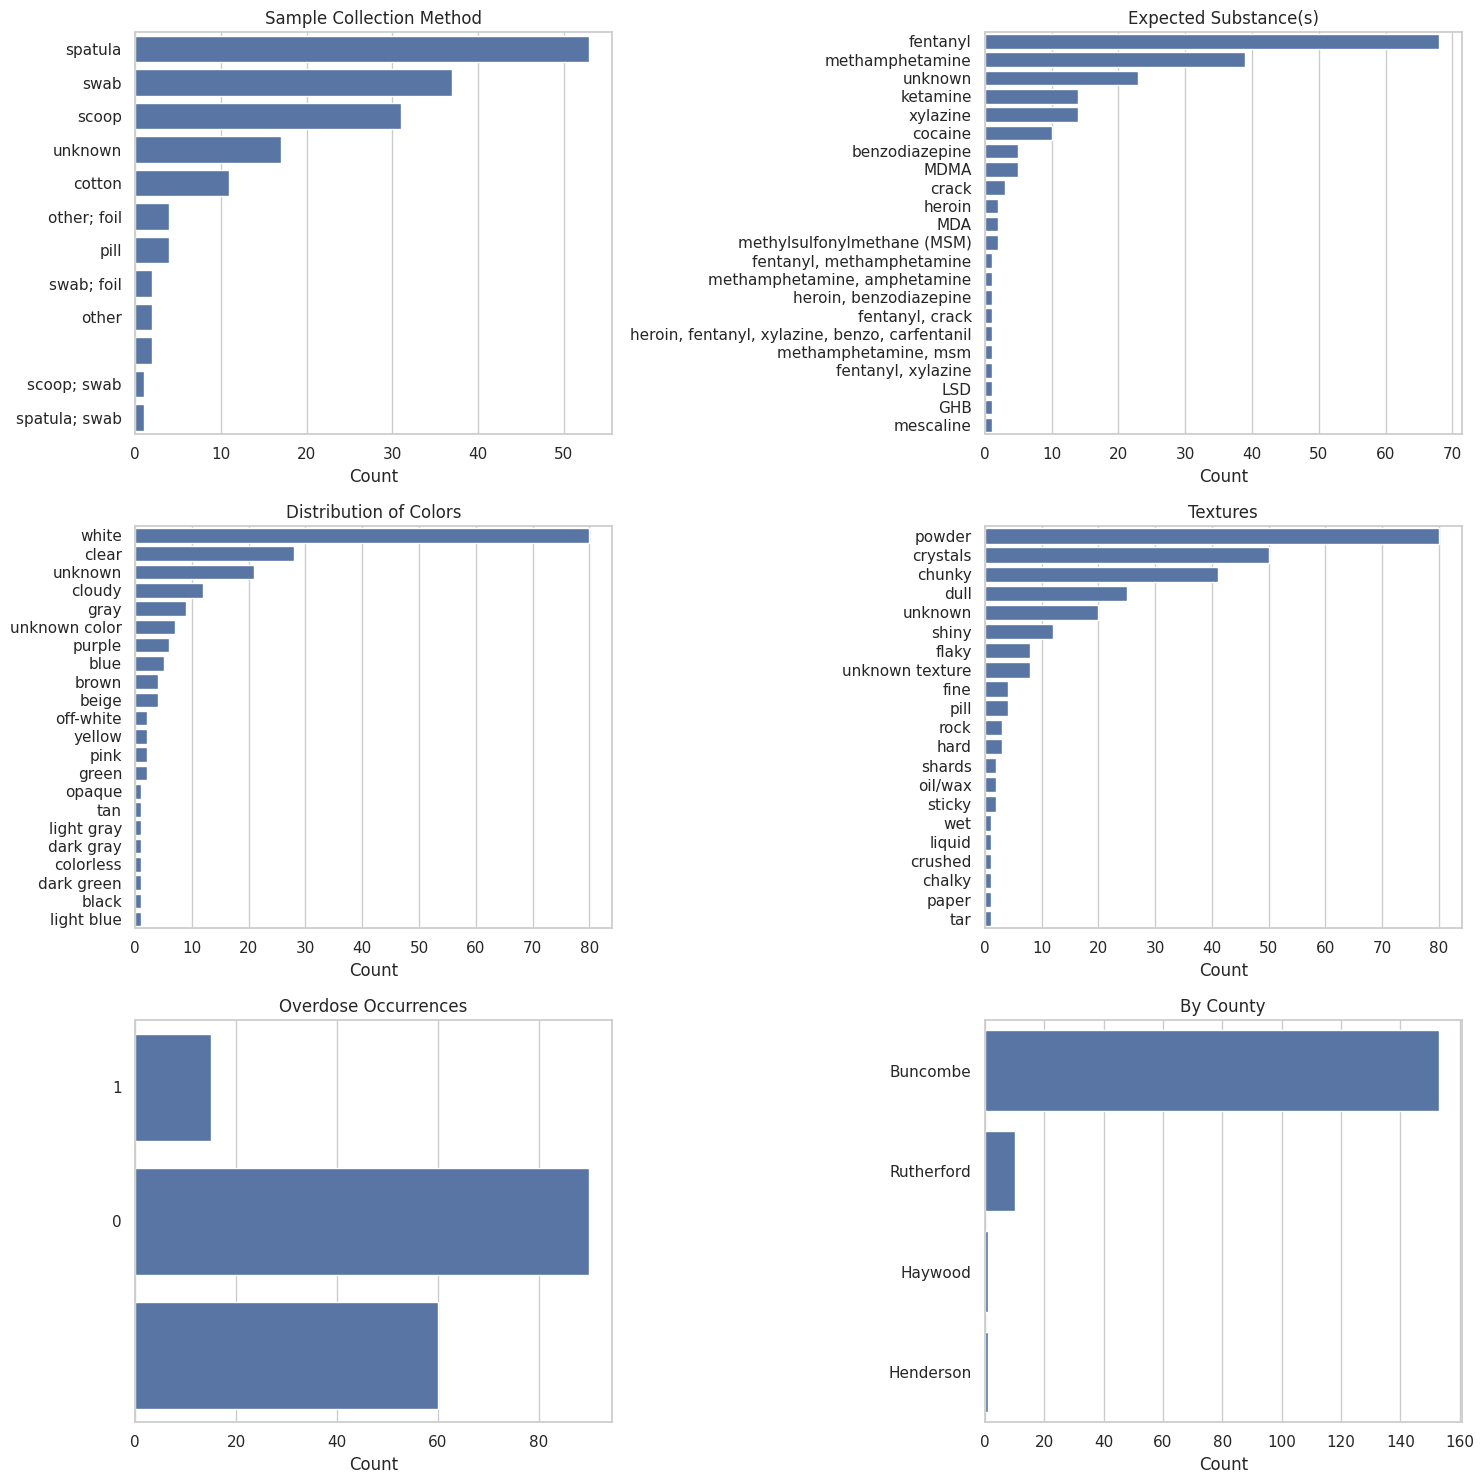

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Set the style of seaborn
sns.set(style="whitegrid")

# Replace blank ('') color and texture entries with 'Unknown'
card_filtered['color'] = card_filtered['color'].replace('', 'unknown')
card_filtered['texture'] = card_filtered['texture'].replace('', 'unknown')
card_filtered['expectedsubstance'] = card_filtered['expectedsubstance'].replace('', 'unknown')

# Remove ' County' from county names
card_filtered['county'] = card_filtered['county'].str.replace(' County', '')

# Helper function to parse and count values

def parse_and_count(column):
    split_lists = column.dropna().apply(lambda x: x.split(';'))
    flat_list = [item.strip() for sublist in split_lists for item in sublist]
    return Counter(flat_list)

# Parse and count expected substances, colors, and textures
expected_substances_count = parse_and_count(card_filtered['expectedsubstance'])
colors_count = parse_and_count(card_filtered['color'])
textures_count = parse_and_count(card_filtered['texture'])

# Convert to DataFrame for plotting

# Sample types ordered by descending frequency
sample_types_ordered = card_filtered['sampletype'].value_counts().index

expected_substances_df = pd.DataFrame(expected_substances_count.items(), columns=['Expected Substance', 'Count']).sort_values(by='Count', ascending=False)
colors_df = pd.DataFrame(colors_count.items(), columns=['Color', 'Count']).sort_values(by='Count', ascending=False)
textures_df = pd.DataFrame(textures_count.items(), columns=['Texture', 'Count']).sort_values(by='Count', ascending=False)

# Counties ordered by descending frequency
top_counties_ordered = card_filtered['county'].value_counts().index

# Create a figure with multiple subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Plot 1: Distribution of sample types
sns.countplot(ax=axes[0, 0], data=card_filtered, y='sampletype', order=sample_types_ordered)
axes[0, 0].set_title('Sample Collection Method')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('')

# Plot 2: Distribution of expected substances
sns.barplot(ax=axes[0, 1], data=expected_substances_df, y='Expected Substance', x='Count')
axes[0, 1].set_title('Expected Substance(s)')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='y', rotation=0)

# Plot 3: Distribution of colors
sns.barplot(ax=axes[1, 0], data=colors_df, y='Color', x='Count')
axes[1, 0].set_title('Distribution of Colors')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('')
axes[1, 0].tick_params(axis='y', rotation=0)

# Plot 4: Distribution of textures
sns.barplot(ax=axes[1, 1], data=textures_df, y='Texture', x='Count')
axes[1, 1].set_title('Textures')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('')
axes[1, 1].tick_params(axis='y', rotation=0)

# Plot 5: Distribution of overdose occurrences
sns.countplot(ax=axes[2, 0], data=card_filtered, y='od')
axes[2, 0].set_title('Overdose Occurrences')
axes[2, 0].set_xlabel('Count')
axes[2, 0].set_ylabel('')

# Plot 6: Distribution of samples by counties
sns.countplot(ax=axes[2, 1], data=card_filtered, y='county', order=top_counties_ordered)
axes[2, 1].set_title('By County')
axes[2, 1].set_xlabel('Count')
axes[2, 1].set_ylabel('')

# Adjust layout
plt.tight_layout()
plt.show()

<hr>

# Substances detected

Customized descriptions of substances detected locally

In [7]:
from IPython.display import display, HTML
import pandas as pd

# Count the number of unique substances identified in the lab_filtered dataframe
unique_substances = lab_filtered['substance'].unique()
unique_substances_count = len(unique_substances)

# Filter chemdict to include only the substances found in lab_filtered
chemdict_filtered = chemdict[chemdict['substance'].isin(unique_substances)]

# Count occurrences of each substance
substance_counts = lab_filtered['substance'].value_counts().reset_index()
substance_counts.columns = ['substance', 'count']

# Merge counts with the chemdict_filtered dataframe
chemdict_filtered = pd.merge(chemdict_filtered, substance_counts, on='substance')

# Select relevant columns for the HTML table
chemdict_filtered = chemdict_filtered[['substance', 'count', 'sixwords']]

# Order by counts in descending order
chemdict_filtered = chemdict_filtered.sort_values(by='count', ascending=False)

# Create an HTML table
html_table_substances = "<table><tr><th>Substance</th><th>Count</th><th>Description</th></tr>"

for index, row in chemdict_filtered.iterrows():
    substance = row['substance']
    count = row['count']
    sixwords = row['sixwords'] if row['sixwords'] != 'None' else ' '
    html_table_substances += f"<tr><td>{substance}</td><td>{count}</td><td>{sixwords}</td></tr>"

html_table_substances += "</table>"

# Display the HTML table
display(HTML(html_table_substances))

Substance,Count,Description
fentanyl,77,"potent opioid, prescription uses, potentially lethal"
4-ANPP,69,leftover/inactive part of fentanyl production
methamphetamine,57,nan
cocaine,34,"Classic upper, coke or crack forms"
lidocaine,22,Common numbing agent with fentanyl
xylazine,21,"Heavy sedative, causes nasty wounds"
ketamine,18,Common nightlife sedative
p-fluorofentanyl,14,"fentanyl-analog, likely more potent and deadly"
ethyl 4-ANPP,12,nan
erythritol,11,"Artificial sweetener, common cut"


## Pick a substance

Select a substance that's been identified in your program's samples to see what else it was found with and comparison to other states\.

In [8]:
selected_substance = 'fentanyl'

In [9]:
# Filter the merged DataFrame for samples containing exactly the selected substance
selected_samples = merged_filtered[merged_filtered['substance'] == selected_substance]['sampleid'].unique()

# Filter the merged DataFrame for the selected samples
samples_with_selected_substance = merged_filtered[merged_filtered['sampleid'].isin(selected_samples)]

# Group by sampleid and list all substances found in each sample
substances_per_sample = samples_with_selected_substance.groupby('sampleid')['substance'].apply(lambda x: list(x)).reset_index()

# Filter out samples with only the selected substance
substances_per_sample['substance_count'] = substances_per_sample['substance'].apply(len)
substances_per_sample_filtered = substances_per_sample[substances_per_sample['substance_count'] > 1]

# Calculate the frequency of each substance found with the selected substance
substance_frequency = substances_per_sample_filtered.explode('substance')['substance'].value_counts().reset_index()
substance_frequency.columns = ['Substance', 'Frequency']

# Sort by frequency
substance_frequency_sorted = substance_frequency.sort_values(by='Frequency', ascending=False)

# Check if substance_frequency_sorted is empty and display message if so
if substance_frequency_sorted.empty:
    print(f'No other substances found with {selected_substance}')
else:
    # Suppress row for the selected substance
    substance_frequency_sorted = substance_frequency_sorted[substance_frequency_sorted['Substance'] != selected_substance]
    # Display the sorted substance frequency table
    display(substance_frequency_sorted)

,Substance,Frequency
1,4-ANPP,68
2,lidocaine,21
3,methamphetamine,21
4,xylazine,20
5,p-fluorofentanyl,14
6,ethyl 4-ANPP,12
7,acetaminophen,10
8,erythritol,10
9,cocaine,9
10,despropionyl p-fluorofentanyl,9


In [10]:
# Count the number of mentions for each substance
substance_counts = merged['substance'].value_counts().reset_index()
substance_counts.columns = ['substance', 'mentions']

# Filter for the selected substance
selected_substance_summary = substance_counts[substance_counts['substance'] == selected_substance]

# Find the states for the selected substance, replace '' state name with 'missing'
states = merged[merged['substance'] == selected_substance].copy()
states['state'] = states['state'].replace('', 'missing')

# Exclude rows where 'state' is NaN
states = states[states['state'].notna()]

# Find the earliest detection date of the selected substance
earliest_detection_date = states['date_complete'].min().strftime('%B %d, %Y')
earliest_local_detection_date = merged_filtered['date_complete'].min().strftime('%B %d, %Y')

# Find the most recent detection date of the selected substance
most_recent_detection_date = states['date_complete'].max().strftime('%B %d, %Y')

state_counts = states['state'].value_counts().reset_index()
state_counts.columns = ['state', 'mentions']

# Calculate the total number of unique samples from each state
state_sample_count = merged.drop_duplicates(subset=['sampleid'])['state'].value_counts().reset_index()
state_sample_count.columns = ['state', 'total_samples']

# Merge state_counts with state_sample_count
tidy_state_mentions = pd.merge(state_counts, state_sample_count, on='state')

# Sort by mentions
sorted_state_mentions = tidy_state_mentions.sort_values(by='mentions', ascending=False)[['state', 'mentions', 'total_samples']]

# Use tabulate library to improve table display
tidy_state_mentions_table = tabulate(sorted_state_mentions, headers='keys', tablefmt='pretty', stralign='left', numalign='left', showindex=False)

#print('Selected Substance Summary:\n', selected_substance_summary.to_string(index=False))
print('\nEarliest UNC Detection Date:\n', earliest_detection_date)
print('\nEarliest program Detection Date:\n', earliest_local_detection_date)
print('\nStates where detected:\n', tidy_state_mentions_table)


Earliest UNC Detection Date:
 January 26, 2022

Earliest program Detection Date:
 November 29, 2022

States where detected:
 +-------+----------+---------------+
| state | mentions | total_samples |
+-------+----------+---------------+
| WA    | 1660     | 3383          |
| NC    | 1320     | 2263          |
| NY    | 1176     | 2005          |
| MI    | 469      | 706           |
| PA    | 373      | 524           |
| NM    | 345      | 591           |
| CO    | 328      | 1062          |
| FL    | 271      | 449           |
| CA    | 235      | 621           |
| OR    | 185      | 512           |
| IL    | 151      | 189           |
| OH    | 132      | 213           |
| WI    | 84       | 151           |
| TN    | 80       | 140           |
| NJ    | 56       | 88            |
| MN    | 49       | 204           |
| VA    | 46       | 87            |
| ME    | 38       | 62            |
| AZ    | 36       | 63            |
| MA    | 35       | 57            |
| TX    | 31       | 20

🏷️ Data Caveats\. We get more more samples from NC, WA, NY, CA, and MI than other states\. Geographic data above should not be construed as prevalence\. And people may preferentially send us samples because they caused unusual reactions\. There is no possible data source on street drugs that is fully generalizable\. Got it? Okay\!

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8a68e8d0-9134-4287-a8d7-fb8aaf6ac7d8' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>